## Prompt
> Find analogues structural of (2S)-N-methyl-2-[[2-(2-methyl-1H-indol-3-yl)acetyl]amino]-N,3-diphenylpropanamide in Enamine REAL database. In the next step, fix central L-phenylalanine and modify its C-terminal (make 10 examples) and N-terminal (another 10 examples) with an emphasis on shape similarity towards the query molecule.

### Step 1 — get the structure, find structural analogues in Enamine REAL

The query is a fully systematic IUPAC name, so it's converted to SMILES via OPSIN's public REST API (`https://www.ebi.ac.uk/opsin/ws/{name}.smi`) rather than hand-parsed — no local install needed, `httpx` (already a `deepmedchem` dependency) is enough.

In [1]:
import httpx
import urllib.parse
from deepmedchem import Client

NAME = "(2S)-N-methyl-2-[[2-(2-methyl-1H-indol-3-yl)acetyl]amino]-N,3-diphenylpropanamide"

encoded = urllib.parse.quote(NAME, safe="")
opsin_response = httpx.get(f"https://www.ebi.ac.uk/opsin/ws/{encoded}.smi", timeout=20)
QUERY = opsin_response.text.strip()
print(f"OPSIN SMILES: {QUERY}")

DATABASE = "enamine-real-v5a"

with Client() as client:
    result = client.search(QUERY, database=DATABASE, method="shape", limit=20)

print(f"\ntop {len(result.hits)} structural analogues by shape similarity in {DATABASE}:")
for hit in result.hits[:10]:
    price = f"${hit.price}" if hit.price is not None else "unavailable"
    print(f"  {hit.rank}  score={hit.score:.4f}  price={price}  {hit.smiles}")

OPSIN SMILES: CN(C([C@H](CC1=CC=CC=C1)NC(CC1=C(NC2=CC=CC=C12)C)=O)=O)C1=CC=CC=C1



top 20 structural analogues by shape similarity in enamine-real-v5a:
  1  score=1.0000  price=$163  Cc1[nH]c2ccccc2c1CC(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
  2  score=0.9766  price=$163  Cc1[nH]c2ccc(F)cc2c1CC(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
  3  score=0.9700  price=$163  Cc1[nH]c2ccc(Cl)cc2c1CC(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
  4  score=0.9624  price=$163  Cc1[nH]c2ccc(Br)cc2c1CC(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
  5  score=0.9184  price=$163  Cc1ccc2[nH]c(C)c(CC(=O)N[C@@H](Cc3ccccc3)C(=O)N(C)c3ccccc3)c2c1
  6  score=0.8839  price=$163  Cc1[nH]c2ccccc2c1C(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
  7  score=0.8705  price=$163  Cc1[nH]c2ccccc2c1CC(F)(F)C(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
  8  score=0.8702  price=$163  Cc1[nH]c2ccccc2c1CC(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)C
  9  score=0.8702  price=$245  Cc1[nH]c2ccccc2c1CC(=O)NC(Cc1ccccc1)C(=O)N(C)C
  10  score=0.8702  price=$245  Cc1[nH]c2ccccc2c1CC(=O)N[C@H](Cc1ccccc1)C(=O)N(C)C


### Step 2 — fix the central L-phenylalanine, vary each terminus

The query molecule is itself an existing Enamine REAL product (rank 1 above, shape score 1.0): `deepmedchem` doesn't support `dmc.substructure()` on this database, so "fix phenylalanine" uses exact `synthon_id` matching instead (see `skills/deepmedchem/references/guidelines.md`, Step 9). Checking its decomposition via `include_synthons=True` shows the reaction fuses phenylalanine **and the C-terminal amide together into one synthon**, with the N-terminal acyl group as the separate, variable synthon:

```
slot 0 (fixed):    CN(C(=O)[C@H](Cc1ccccc1)N[C](=O)[U])c1ccccc1   # phenylalanine + C-terminal
slot 1 (variable): Cc1[nH]c2ccccc2c1[CH2][U]                      # N-terminal acyl group
```

**N-terminal variation is therefore directly achievable** — filter for hits sharing slot 0's exact `synthon_id`, ranked by shape similarity to the query.

**C-terminal variation turned out not to be achievable for this exact building block.** The complementary disconnection — phenylalanine fused with the N-terminal acyl group, C-terminal left open — was searched for directly: probed with several different concrete C-terminal caps, searched broadly from the free-acid intermediate (`...C(=O)O`, itself a real product) across two similarity metrics at the maximum limit (400+ hits inspected in total), and found **zero** instances of that decomposition. Every reaction found either fuses phenylalanine+C-terminal (the pattern above) or leaves the C-terminus as a bare, uncapped acid — Enamine REAL simply doesn't appear to offer a reaction that couples a fixed N-acyl-phenylalanine acid with a variable amine to form this exact C-terminal amide. This is reported as infeasible for this molecule/database rather than substituted with an approximate (non-exact-synthon) workaround.

In [2]:
PHE_AND_CTERM_SYNTHON_ID = "st_ffb9611ac94f1e52c6353aed"
LIMIT = 200
TOP_N = 10

with Client() as client:
    result = client.search(
        QUERY, database=DATABASE, method="shape", limit=LIMIT, include_synthons=True
    )
    matches = [
        hit for hit in result.results
        if any(s["synthon_id"] == PHE_AND_CTERM_SYNTHON_ID for s in (hit.get("synthons") or []))
    ]

print(f"{len(matches)} exact matches (phenylalanine + C-terminal fixed, N-terminal varies)")

top = sorted(matches, key=lambda h: h["score"], reverse=True)[:TOP_N]
for hit in top:
    print(f"shape={hit['score']:.4f}  {hit['smiles']}")

41 exact matches (phenylalanine + C-terminal fixed, N-terminal varies)
shape=1.0000  Cc1[nH]c2ccccc2c1CC(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
shape=0.9184  Cc1ccc2[nH]c(C)c(CC(=O)N[C@@H](Cc3ccccc3)C(=O)N(C)c3ccccc3)c2c1
shape=0.8839  Cc1[nH]c2ccccc2c1C(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
shape=0.8828  Cc1[nH]c2cccnc2c1C(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
shape=0.8778  Cc1[nH]c2ncccc2c1C(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
shape=0.8705  Cc1[nH]c2ccccc2c1CC(F)(F)C(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
shape=0.8642  Cc1[nH]c2ccccc2c1C(=O)C(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
shape=0.8577  Cc1[nH]c2ccc(F)cc2c1C(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
shape=0.8575  Cc1[nH]c2ccccc2c1SCC(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
shape=0.8556  Cc1[nH]c2ccc(Cl)cc2c1C(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1


### Step 3 — 2x5 grid of the 10 N-terminal variants

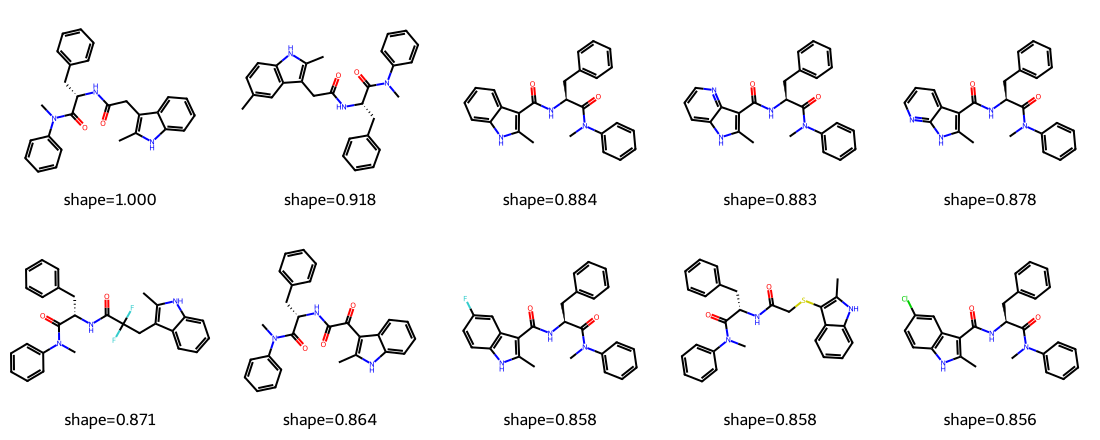

In [3]:
from rdkit import Chem
from rdkit.Chem import Draw

mols = [Chem.MolFromSmiles(hit["smiles"]) for hit in top]
legends = [f"shape={hit['score']:.3f}" for hit in top]

Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(220, 220), legends=legends)